In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [47]:
df=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')


In [7]:
df.shape

(42000, 785)

In [8]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
21014,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
import matplotlib.pyplot as plt

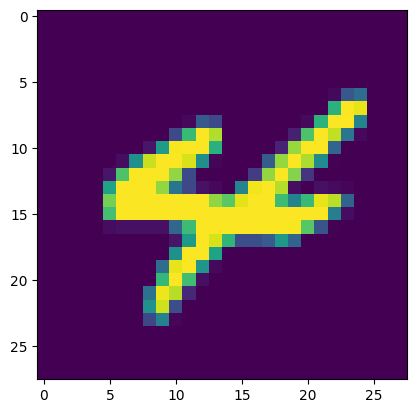

In [14]:
plt.imshow(df.iloc[21014,1:].values.reshape(28,28))

In [48]:
X =df.iloc[:,1:]
Y =df.iloc[:,0]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [24]:
X_train.shape

(33600, 784)

In [27]:
from sklearn.neighbors import KNeighborsClassifier

In [28]:
knn = KNeighborsClassifier()

In [29]:
knn.fit(X_train, Y_train)

KNeighborsClassifier()

In [31]:
Y_pred = knn.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

accuracy_score(Y_test, Y_pred)

0.9648809523809524

In [33]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()

In [36]:
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

In [68]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=50)

In [69]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf  = pca.transform(X_test)

In [70]:
X_train_trf.shape

(33600, 50)

In [72]:
knn = KNeighborsClassifier()

In [73]:
knn.fit(X_train_trf, Y_train)

KNeighborsClassifier()

In [74]:
Y_pred = knn.predict(X_test_trf)

In [75]:
accuracy_score(Y_test, Y_pred)

0.7523809523809524

In [77]:
for i in range(1,101):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf  = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf, Y_train)

    Y_pred = knn.predict(X_test_trf)

    print(accuracy_score(Y_test, Y_pred))

0.18285714285714286
0.13916666666666666
0.2286904761904762
0.26261904761904764
0.3601190476190476
0.3838095238095238
0.4276190476190476
0.4666666666666667
0.4751190476190476
0.4679761904761905
0.47285714285714286
0.48928571428571427
0.585
0.6004761904761905
0.6072619047619048
0.6288095238095238
0.6105952380952381
0.611904761904762
0.6225
0.6551190476190476
0.6546428571428572
0.6557142857142857
0.6667857142857143
0.6677380952380952
0.6891666666666667
0.6919047619047619
0.6958333333333333
0.7014285714285714
0.6984523809523809
0.699047619047619
0.7051190476190476
0.7129761904761904
0.7152380952380952
0.715
0.7233333333333334
0.7282142857142857
0.7323809523809524
0.736904761904762
0.7352380952380952
0.7363095238095239
0.7367857142857143
0.7386904761904762
0.7395238095238095
0.7416666666666667
0.7440476190476191
0.7455952380952381
0.75
0.7497619047619047
0.7509523809523809
0.7523809523809524
0.7532142857142857
0.7541666666666667
0.7536904761904762
0.7539285714285714
0.7554761904761905
0.755

In [79]:
##Transforming to a 2D cooordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf  = pca.transform(X_test)


In [80]:
X_train_trf 

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

In [83]:
import plotly.express as px

Y_train_trf = Y_train.astype(str)

fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    color=Y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [84]:
##Transforming to a 3D cooordinate system
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf  = pca.transform(X_test)

In [86]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]])

In [87]:
import plotly.express as px

Y_train_trf = Y_train.astype(str)

fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=Y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()